# Identifying Social Media Engagement Groups Using K-Means Clustering

# **Problem Statement:**

Social media platforms generate large amounts of engagement data, making it difficult to identify patterns in user interactions. This project aims to use the K-Means Clustering algorithm to group Facebook Live posts based on engagement metrics such as likes, comments, shares, and reactions. The goal is to discover meaningful clusters that help understand post performance and audience engagement behavior.


# 📈 Workflow Architecture

# 📊 Data Structure


# Data Structure

The dataset contains information about **Facebook Live posts** and their engagement metrics. Each row represents a unique Facebook post, while the columns contain details about the post type, publication information, and user interactions such as reactions, comments, and shares. The dataset is designed to analyze social media engagement patterns, identify similar post behaviors, and discover hidden groups of posts using clustering techniques.

* **Total Rows:** 7,050 (Facebook posts)
* **Total Columns:** 12
* **Independent Variables:** Number of Reactions, Comments, Shares, Likes, Loves, Wows, Hahas, Sads, and Angrys
* **Identifier Columns:** Status ID, Status Published
* **Categorical Variable:** Status Type (Photo, Video, Link, Status)
* **Problem Type:** Clustering / Unsupervised Learning
* **Model Used:** K-Means Clustering 


# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix,classification_report, silhouette_score
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=(8,3) #(width,heigth)
plt.rcParams['figure.dpi']=150 #pixil
sns.set_theme(style='darkgrid',palette='viridis')

# Load File

In [ ]:
df=pd.read_csv("Live.csv")
df

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7045,1050855161656896_1061863470556065,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,1050855161656896_1061334757275603,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,1050855161656896_1060126464063099,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,1050855161656896_1058663487542730,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0


# Data Understanding

In [3]:
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0


In [4]:
df.tail()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
7045,1050855161656896_1061863470556065,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,1050855161656896_1061334757275603,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,1050855161656896_1060126464063099,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,1050855161656896_1058663487542730,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0
7049,1050855161656896_1050858841656528,photo,9/10/2016 10:30,17,0,0,17,0,0,0,0,0


In [5]:
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')

Number of Rows: 7050
Number of Columns: 12


In [6]:
df.describe()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
mean,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191
std,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000
max,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_id         7050 non-null   object
 1   status_type       7050 non-null   object
 2   status_published  7050 non-null   object
 3   num_reactions     7050 non-null   int64 
 4   num_comments      7050 non-null   int64 
 5   num_shares        7050 non-null   int64 
 6   num_likes         7050 non-null   int64 
 7   num_loves         7050 non-null   int64 
 8   num_wows          7050 non-null   int64 
 9   num_hahas         7050 non-null   int64 
 10  num_sads          7050 non-null   int64 
 11  num_angrys        7050 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 661.1+ KB


In [8]:
df.dtypes

status_id           object
status_type         object
status_published    object
num_reactions        int64
num_comments         int64
num_shares           int64
num_likes            int64
num_loves            int64
num_wows             int64
num_hahas            int64
num_sads             int64
num_angrys           int64
dtype: object

# Data Quality Check 

In [9]:
df.duplicated().sum()

np.int64(51)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isna().sum()

status_id           0
status_type         0
status_published    0
num_reactions       0
num_comments        0
num_shares          0
num_likes           0
num_loves           0
num_wows            0
num_hahas           0
num_sads            0
num_angrys          0
dtype: int64

# Exploratory Data Analysis

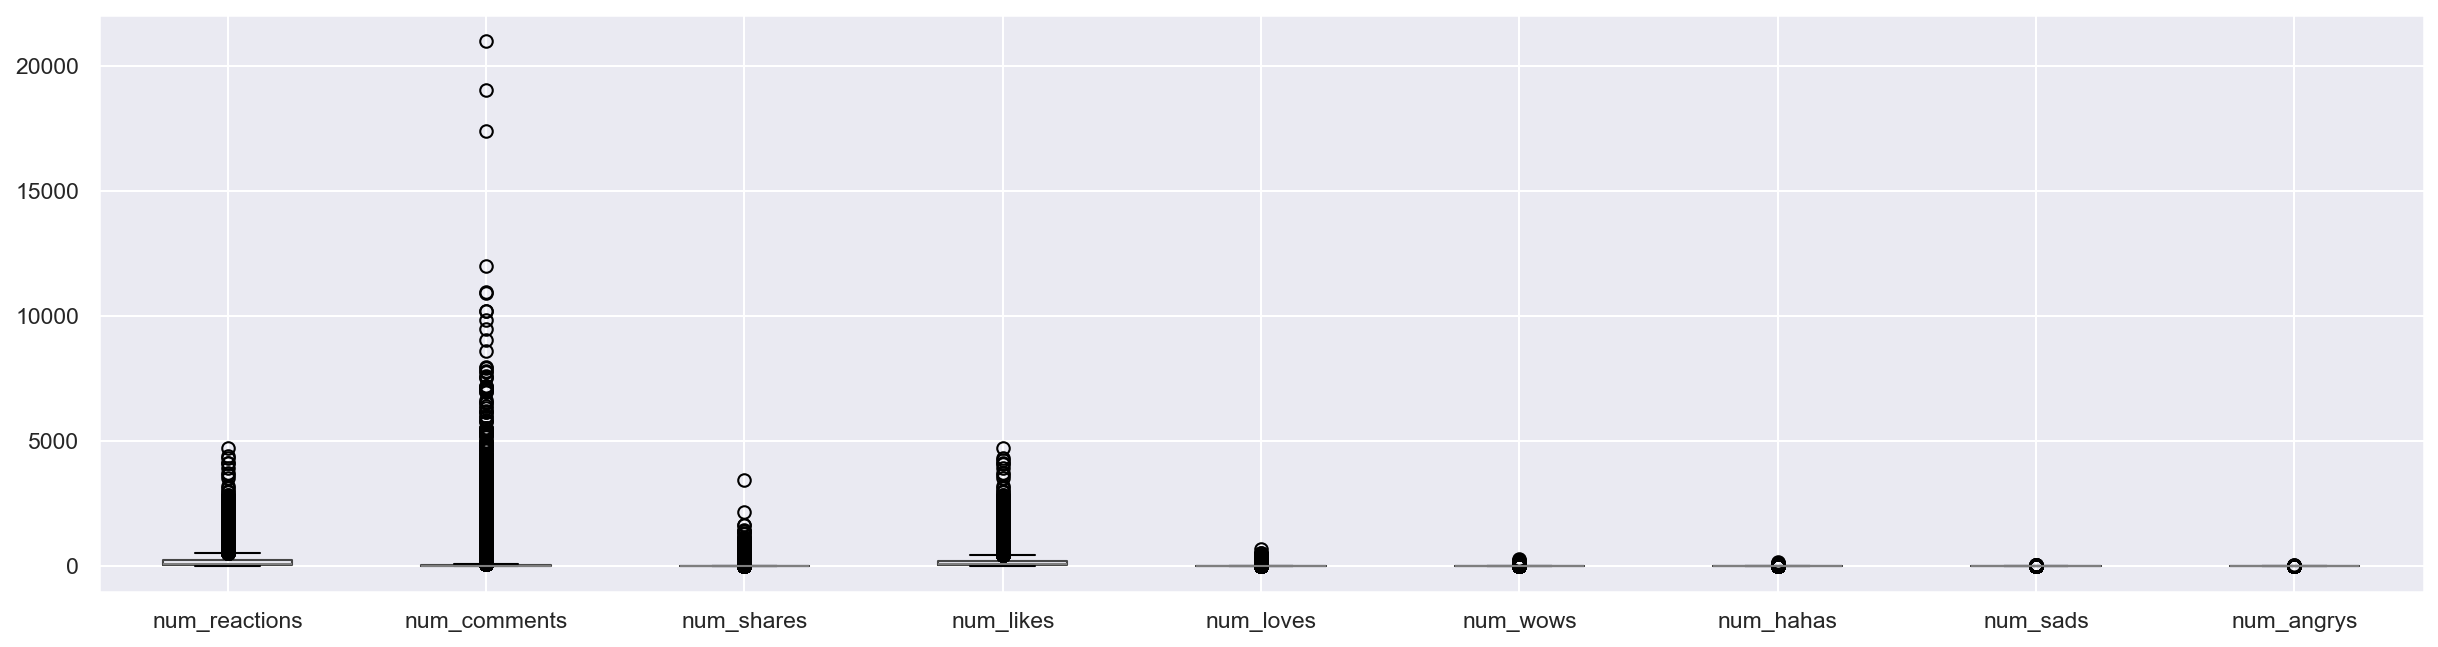

In [13]:
plt.figure(figsize=(20,5))
df.boxplot()
plt.show()

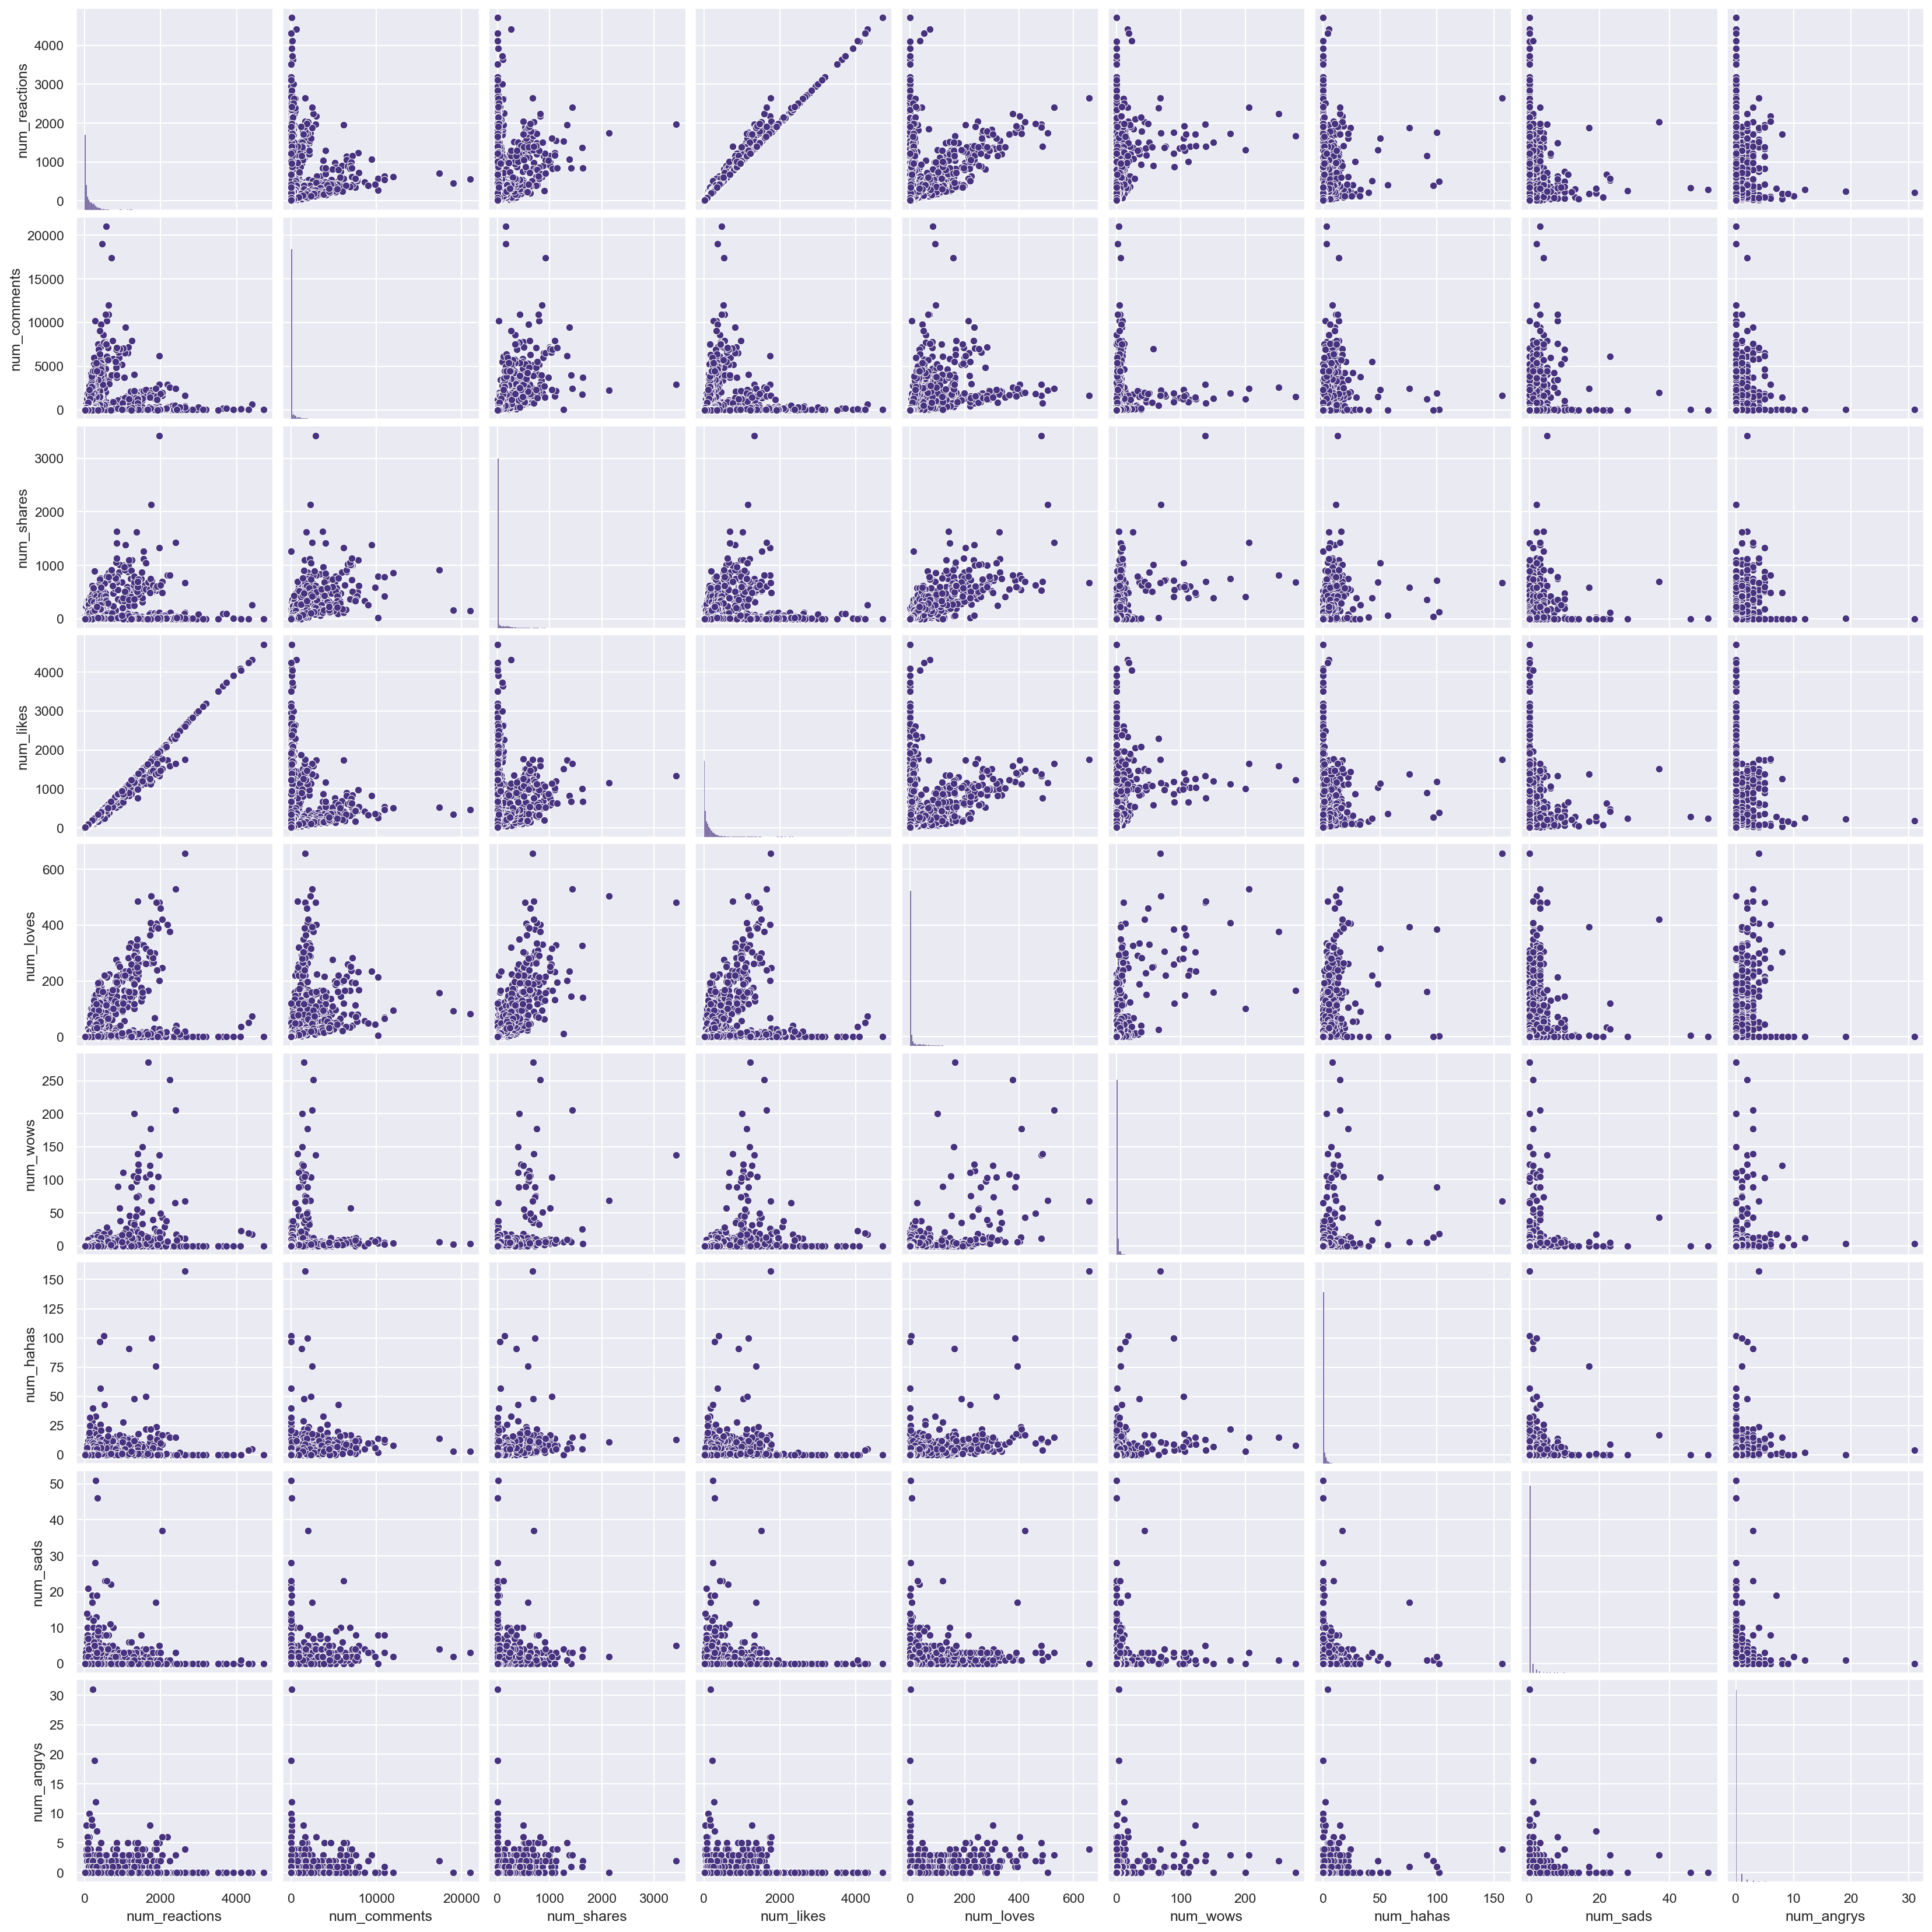

In [14]:
sns.pairplot(df)
plt.show()

# Dropping Unnecessary Column

In [15]:
df.drop(columns=['status_id','status_published'],inplace=True)

In [16]:
df.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,video,529,512,262,432,92,3,1,1,0
1,photo,150,0,0,150,0,0,0,0,0
2,video,227,236,57,204,21,1,1,0,0
3,photo,111,0,0,111,0,0,0,0,0
4,photo,213,0,0,204,9,0,0,0,0


# Encoding

In [17]:
df=pd.get_dummies(df,columns=['status_type'],dtype=int)

In [18]:
df.head()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type_link,status_type_photo,status_type_status,status_type_video
0,529,512,262,432,92,3,1,1,0,0,0,0,1
1,150,0,0,150,0,0,0,0,0,0,1,0,0
2,227,236,57,204,21,1,1,0,0,0,0,0,1
3,111,0,0,111,0,0,0,0,0,0,1,0,0
4,213,0,0,204,9,0,0,0,0,0,1,0,0


# Scaling

In [19]:
si=StandardScaler()
scaled_data=si.fit_transform(df)
scaled_data

array([[ 0.67131834,  0.32088561,  1.67938232, ..., -1.24115747,
        -0.23252154,  1.41421356],
       [-0.16560635, -0.25266868, -0.30490291, ...,  0.80569954,
        -0.23252154, -0.70710678],
       [ 0.00442848,  0.011704  ,  0.12679273, ..., -1.24115747,
        -0.23252154,  1.41421356],
       ...,
       [-0.49242655, -0.25266868, -0.30490291, ...,  0.80569954,
        -0.23252154, -0.70710678],
       [ 0.2782508 , -0.239226  , -0.13828354, ...,  0.80569954,
        -0.23252154, -0.70710678],
       [-0.45930288, -0.25266868, -0.30490291, ...,  0.80569954,
        -0.23252154, -0.70710678]], shape=(6999, 13))

# Model Building

In [20]:
km=KMeans()
y_pred=km.fit_predict(scaled_data)
y_pred

array([2, 0, 1, ..., 0, 0, 0], shape=(6999,), dtype=int32)

In [21]:
print(f'Cluster Center: {km.cluster_centers_}')
print('*'*100)
print(f'Inertia: {km.inertia_}')

Cluster Center: [[-0.30043955 -0.24028763 -0.29225081 -0.27977248 -0.28776624 -0.0834226
  -0.14113037 -0.11320513 -0.13406813 -0.09530501  0.80569954 -0.23252154
  -0.70710678]
 [-0.19660398 -0.13565568 -0.12893562 -0.18785706 -0.1232497  -0.10674326
  -0.08929767 -0.10591938 -0.11151607 -0.09530501 -1.24115747 -0.23252154
   1.41421356]
 [ 0.15120388  1.24204838  1.53134456  0.01335292  1.45348983  0.05440585
   0.5972397   0.69524859  0.62394199 -0.09530501 -1.18574341 -0.23252154
   1.35678357]
 [ 0.18657218 -0.2172084  -0.28686726  0.21944377 -0.27924849 -0.02795258
  -0.14552777  0.0984293  -0.12073727 -0.09530501 -1.24115747  4.30067689
  -0.70710678]
 [ 0.32052291 -0.24628518 -0.27160308  0.36328888 -0.31044152 -0.12176801
  -0.16778472 -0.15705926 -0.15999034 10.4926278  -1.24115747 -0.23252154
  -0.70710678]
 [ 1.61966821  4.95162118  4.38420251  1.2477322   4.12987694  0.81116801
   1.96609426  1.54647682  3.29103891 -0.09530501 -1.16604345 -0.23252154
   1.33636694]
 [ 3.86

# Elbow Method

In [22]:
wcss=[]
for i in range(2,15):
    km=KMeans(n_clusters=i,random_state=0)
    km.fit_predict(scaled_data)
    wcss.append(km.inertia_)

In [23]:
wcss

[74727.67926594264,
 62140.78051971948,
 54923.92270918896,
 45394.16369307593,
 41755.533140436244,
 36428.89720700326,
 29295.685777713097,
 26655.214175210727,
 24624.333874199936,
 22403.763563723813,
 19138.083863478532,
 18312.642263337093,
 17491.017212022267]

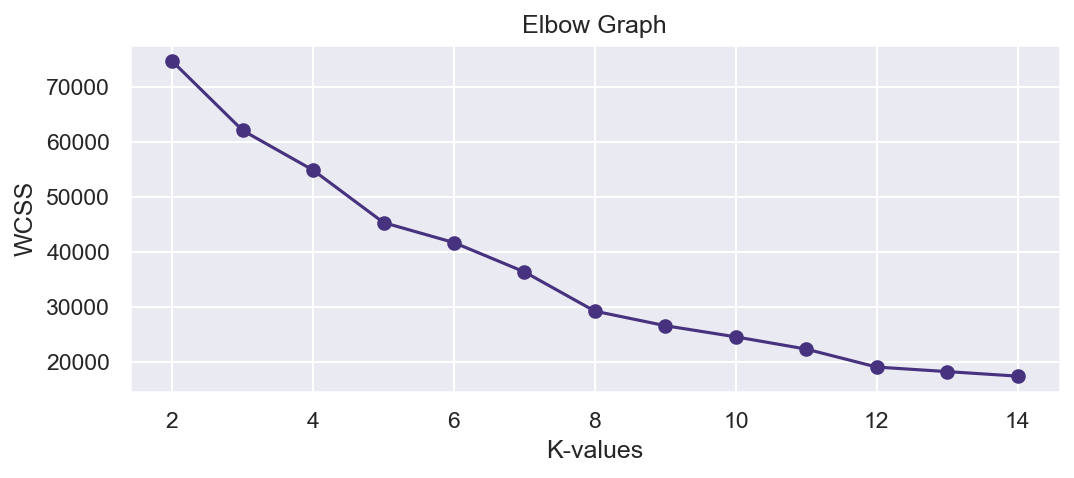

In [24]:
plt.plot(range(2,15),wcss,marker='o')
plt.xlabel('K-values')
plt.ylabel('WCSS')
plt.title('Elbow Graph')
plt.show()

# Final Model Building

In [25]:
km=KMeans(n_clusters=12,random_state=42)
y_pred=km.fit_predict(scaled_data)
y_pred

array([5, 0, 1, ..., 0, 0, 0], shape=(6999,), dtype=int32)

In [26]:
print(f'Cluster Center: {km.cluster_centers_}')
print('*'*100)
print(f'Inertia: {km.inertia_}')

Cluster Center: [[-3.00231501e-01 -2.40290375e-01 -2.91818147e-01 -2.79571046e-01
  -2.87497704e-01 -8.33927459e-02 -1.41238105e-01 -1.13853234e-01
  -1.39818621e-01 -9.53050103e-02  8.05699537e-01 -2.32521537e-01
  -7.07106781e-01]
 [-2.00303139e-01 -1.45053410e-01 -1.67075348e-01 -1.88103546e-01
  -1.60498241e-01 -1.08955591e-01 -1.03176245e-01 -9.77190419e-02
  -1.27113931e-01 -9.53050103e-02 -1.24115747e+00 -2.32521537e-01
   1.41421356e+00]
 [ 2.43368464e+00  3.18580902e+00  5.30316106e+00  1.87543819e+00
   5.94879465e+00  1.67857120e+00  5.19842768e+00  1.10182503e+00
   3.36014531e+00 -9.53050103e-02 -1.17177249e+00 -2.32521537e-01
   1.34230440e+00]
 [ 1.86572183e-01 -2.17208396e-01 -2.86867259e-01  2.19443768e-01
  -2.79248494e-01 -2.79525836e-02 -1.45527767e-01  9.84292958e-02
  -1.20737267e-01 -9.53050103e-02 -1.24115747e+00  4.30067689e+00
  -7.07106781e-01]
 [ 3.86011847e+00 -1.88603150e-01 -2.13856741e-01  4.00127824e+00
  -2.57724010e-01  6.79644472e-02 -1.30645653e-01 

# Analyse the cluster

In [27]:
df['Cluster']=y_pred

In [28]:
df.head()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type_link,status_type_photo,status_type_status,status_type_video,Cluster
0,529,512,262,432,92,3,1,1,0,0,0,0,1,5
1,150,0,0,150,0,0,0,0,0,0,1,0,0,0
2,227,236,57,204,21,1,1,0,0,0,0,0,1,1
3,111,0,0,111,0,0,0,0,0,0,1,0,0,0
4,213,0,0,204,9,0,0,0,0,0,1,0,0,0


In [29]:
df.groupby('Cluster').mean()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type_link,status_type_photo,status_type_status,status_type_video
Cluster,,,,,,,,,,,,,
0,89.035218,11.049851,1.727679,87.069940,1.221726,0.525298,0.137153,0.063988,0.013889,0.0,1.000000,0.00000,0.000000
1,134.287617,96.065912,18.198402,127.271638,6.314913,0.302264,0.288282,0.087883,0.022636,0.0,0.000000,0.00000,1.000000
2,1327.084746,3069.457627,740.474576,1034.237288,251.322034,15.898305,21.338983,1.864407,2.423729,0.0,0.033898,0.00000,0.966102
3,309.483483,31.654655,2.381381,306.396396,1.552553,1.009009,0.120120,0.378378,0.027027,0.0,0.000000,1.00000,0.000000
4,1973.043011,57.189964,12.021505,1968.584229,2.415771,1.845878,0.179211,0.014337,0.003584,0.0,0.677419,0.09319,0.229391
5,292.546573,920.987698,230.513181,213.212654,74.144112,1.574692,2.488576,0.499121,0.616872,0.0,0.014060,0.00000,0.985940
6,370.142857,5.698413,4.396825,369.619048,0.301587,0.190476,0.031746,0.000000,0.000000,1.0,0.000000,0.00000,0.000000
7,1551.434783,1606.782609,830.652174,1105.347826,299.478261,131.826087,11.478261,1.521739,1.782609,0.0,0.000000,0.00000,1.000000
8,533.888889,13500.777778,522.888889,425.444444,91.666667,4.666667,8.222222,3.555556,0.333333,0.0,0.111111,0.00000,0.888889


# Evaluation

In [30]:
silhouette_score(scaled_data,y_pred)

0.6921623739540101

# Conclusion

The K-Means Clustering algorithm was applied to the Facebook Live dataset to group posts based on their engagement metrics, including reactions, comments, shares, likes, and other user interactions. The model achieved a **Silhouette Score of 0.6955**, indicating **good cluster separation and high-quality clustering performance**.

The resulting clusters represent distinct levels of user engagement, ranging from low-engagement posts to highly viral posts with exceptionally high numbers of reactions, comments, and shares. The analysis reveals that different types of Facebook posts attract varying levels of audience interaction, allowing meaningful segmentation of content based on engagement behavior.

Overall, the K-Means model successfully identified well-defined groups of Facebook posts, providing valuable insights into content performance and user engagement patterns. The high silhouette score confirms that the clusters are well-formed and suitable for further analysis and decision-making.

**Result:**

* **Algorithm:** K-Means Clustering
* **Number of Clusters (K):** 12
* **Silhouette Score:** 0.6955
* **Interpretation:** Good clustering performance with well-separated and meaningful engagement-based groups.
